In [26]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False

# symbols: list[str] = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT", "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
#     "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
#     "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
#     "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
#     "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
#     "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
# ]



# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "1m"
# start_date: str = "2024-09-01"
# end_date: str = "2025-08-31"
# output_dir: str = "mmpair-strategy/1m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


# Preload

In [27]:
from pathlib import Path
import copy
import pandas as pd
import datetime
from datetime import datetime

output_dir = "mmpair-strategy/1m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}

start_time = datetime(2024, 11, 1)
end_time = datetime(2025, 10, 31)
    
for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]
        
        if df.index.min() <= start_time:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")


# chosen = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'TRXUSDT', 'DOTUSDT', 'LTCUSDT', 'UNIUSDT', 'ATOMUSDT', 'ETCUSDT', 'ICPUSDT', 'APTUSDT', 'FILUSDT', 'NEARUSDT', 'HBARUSDT', 'INJUSDT', 'OPUSDT', 'ARBUSDT', 'SUIUSDT', 'SEIUSDT', 'RENDERUSDT', 'TIAUSDT', 'FTMUSDT', 'EGLDUSDT', 'AAVEUSDT', 'GALAUSDT', 'IMXUSDT', 'WIFUSDT', 'PENGUUSDT', 'TRUMPUSDT', 'POLUSDT', 'ENSUSDT', 'JUPUSDT', 'PYTHUSDT', 'ORDIUSDT', 'MOVRUSDT', 'DYMUSDT', 'NOTUSDT', 'SPXUSDT']
chosen = [           "BTCUSDT",
            "ETHUSDT",
            "BNBUSDT",
            "SOLUSDT",
            "XRPUSDT",
            "ADAUSDT",
            "DOGEUSDT",
            "AVAXUSDT",
            "LINKUSDT",
            "TRXUSDT",
            
            "DOTUSDT",
            "MATICUSDT",
            "LTCUSDT",
            "UNIUSDT",
            "ATOMUSDT",
            "ETCUSDT",
            "ICPUSDT",
            "APTUSDT",
            "FILUSDT",
            
            # "NEARUSDT",
            # "HBARUSDT",
            # "INJUSDT",
            # "OPUSDT",
            # "ARBUSDT",
            # "SUIUSDT",
            # "SEIUSDT",
            # "RENDERUSDT",
            # "TIAUSDT",
            # "FTMUSDT",
            # "EGLDUSDT",
            # "AAVEUSDT",
            # "GALAUSDT",
            # "IMXUSDT",
            # "PEPEUSDT",
            # "SHIBUSDT",
            # "FLOKIUSDT",
            # "BONKUSDT",
            # "WIFUSDT",
            # "PENGUUSDT",
            # "TRUMPUSDT",
            # "POLUSDT",
            # "ENSUSDT",
            # "JUPUSDT",
            # "PYTHUSDT",
            # "ORDIUSDT",
            # "SATOSHIUSDT",
            # "SATSUSDT",
            # "MOVRUSDT",
            # "DYMUSDT",
            # "NOTUSDT",
            # "MAGAUSDT",
            # "SPXUSDT"
            ]

hedge_list = {k: v for k, v in coins_dict.items() if k in chosen}


temp = copy.copy(hedge_list)

Processing symbol: IMXUSDT, length: 1140480
Processing symbol: SOLUSDT, length: 1140480
Processing symbol: NOTUSDT, length: 768240
Processing symbol: BONKUSDT, length: 988800
Processing symbol: LTCUSDT, length: 1140480
Processing symbol: ORDIUSDT, length: 1043280
Processing symbol: SUIUSDT, length: 1140480
Processing symbol: POLUSDT, length: 595560
Processing symbol: JUPUSDT, length: 920640
Processing symbol: NEARUSDT, length: 1140480
Processing symbol: ATOMUSDT, length: 1140480
Processing symbol: APTUSDT, length: 1140480
Processing symbol: GALAUSDT, length: 1140480
Processing symbol: ARBUSDT, length: 1140480
Processing symbol: TRXUSDT, length: 1140480
Processing symbol: BNBUSDT, length: 1140480
Processing symbol: DOTUSDT, length: 1140480
Processing symbol: FILUSDT, length: 1140480
Processing symbol: ETCUSDT, length: 1140480
Processing symbol: RENDERUSDT, length: 666240
Processing symbol: FLOKIUSDT, length: 1140480
Processing symbol: BTCUSDT, length: 1140480
Processing symbol: LINKUSDT

In [28]:
hedge_list = temp

In [29]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random
import os


In [30]:
len(hedge_list.keys())

19

In [31]:
for symbol, df in hedge_list.items():
    print(df.index.min(), df.index.max())
    hedge_list[symbol] = df[(df.index >= start_time) & (df.index <= end_time)]

2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2024-09-10 02:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2025-10-31 23:59:59.999999
2023-09-01 00:00:59.999999 2

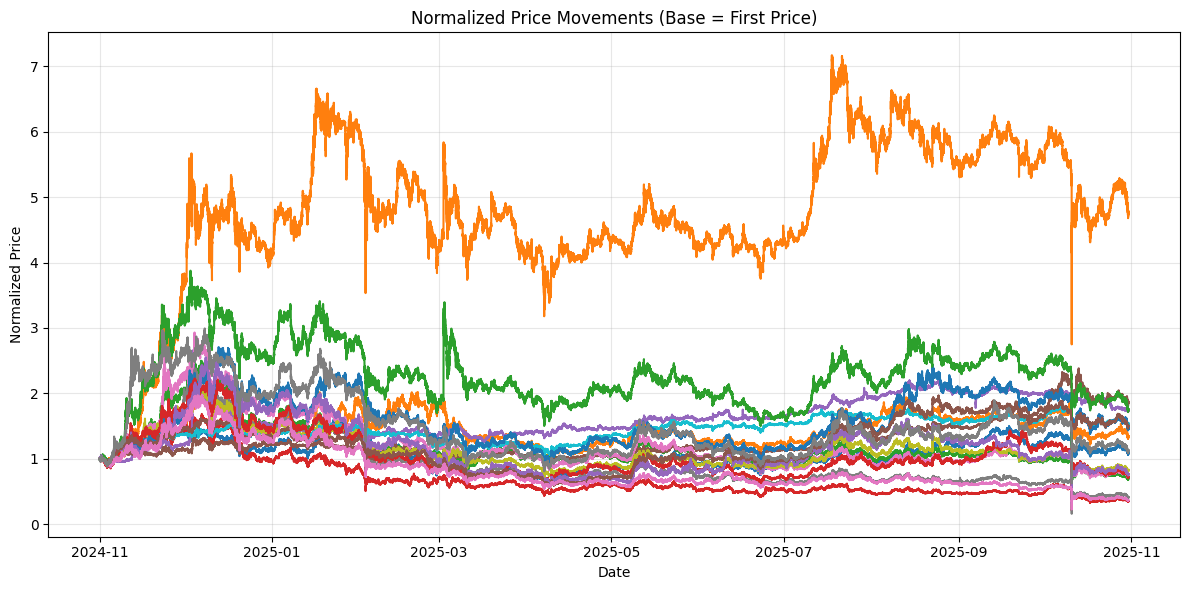

In [32]:
plt.figure(figsize=(12, 6))
for symbol, df in hedge_list.items():
    if len(df) > 0:  # Check if dataframe is not empty
        # Normalize to first price
        normalized_prices = df["Close"] / df["Close"].iloc[0]
        plt.plot(df.index, normalized_prices, label=symbol)

plt.title('Normalized Price Movements (Base = First Price)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## Para

In [33]:

FORWARD_WINDOW = 6
BACK_WINDOW = 12
BULLET_SIZE = 50

# Stats

## AMIHUD

In [34]:
amihud_window = BACK_WINDOW
for symbol, df in hedge_list.items():
    df["Close_x_Volume"] = df["Close"] * df["Volume"]
    df["Amihud"] = df["Close_x_Volume"].diff().abs()/df["Close_x_Volume"].rolling(window=amihud_window).mean() 
    df.dropna(inplace=True)   

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_11720/3147095631.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Close_x_Volume"] = df["Close"] * df["Volume"]
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_11720/3147095631.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Amihud"] = df["Close_x_Volume"].diff().abs()/df["Close_x_Volume"].rolling(window=amihud_window).mean()
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_11720/3147095631.py:5: SettingWithCopyWa

## Split

In [35]:
# Remove MATICUSDT from hedge_list

if 'MATICUSDT' in hedge_list:
    del hedge_list['MATICUSDT']
    print("MATICUSDT removed from hedge_list")
else:
    print("MATICUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

if 'FTMUSDT' in hedge_list:
    del hedge_list['FTMUSDT']
    print("FTMUSDT removed from hedge_list")
else:
    print("FTMUSDT not found in hedge_list")

print(f"Remaining symbols in hedge_list: {list(hedge_list.keys())}")

MATICUSDT removed from hedge_list
Remaining symbols in hedge_list: ['SOLUSDT', 'LTCUSDT', 'ATOMUSDT', 'APTUSDT', 'TRXUSDT', 'BNBUSDT', 'DOTUSDT', 'FILUSDT', 'ETCUSDT', 'BTCUSDT', 'LINKUSDT', 'XRPUSDT', 'ADAUSDT', 'AVAXUSDT', 'UNIUSDT', 'ETHUSDT', 'ICPUSDT', 'DOGEUSDT']
FTMUSDT not found in hedge_list
Remaining symbols in hedge_list: ['SOLUSDT', 'LTCUSDT', 'ATOMUSDT', 'APTUSDT', 'TRXUSDT', 'BNBUSDT', 'DOTUSDT', 'FILUSDT', 'ETCUSDT', 'BTCUSDT', 'LINKUSDT', 'XRPUSDT', 'ADAUSDT', 'AVAXUSDT', 'UNIUSDT', 'ETHUSDT', 'ICPUSDT', 'DOGEUSDT']


In [36]:
split_date = datetime(2025, 10, 1)

train_list = {}
test_list = {}

for symbol, df in hedge_list.items():
    train_list[symbol] = df[df.index < split_date]
    test_list[symbol] = df[df.index >= split_date]

In [37]:
data_list = test_list
common_index = None
for symbol, df in data_list.items():
    if common_index is None:
        common_index = df.index
    else:
        common_index = common_index.intersection(df.index)

## Regress

In [38]:

back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


# btc_close = deque(btc['Close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['Close'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


# btc_volume = deque(btc['Volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['Volume'][:back_window], maxlen=back_window) for name, df in hedge_list.items()}


xy_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
xx_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
yy_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
x_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}
y_1 = {name: deque(np.array([0]*back_window)) for name in hedge_list.keys()}


xy_1_sum = {name: 0 for name in hedge_list.keys()}
xx_1_sum = {name: 0 for name in hedge_list.keys()}
yy_1_sum = {name: 0 for name in hedge_list.keys()}
x_1_sum = {name: 0 for name in hedge_list.keys()}
y_1_sum = {name: 0 for name in hedge_list.keys()}

# Trade

In [39]:
lc = None
sc = None
sam = 0
dif = 0

In [42]:
# Initialize coef_records
coef_records = {}

revenues = []

stats_1 = [] # Amihud of selected pairs
stats_2 = [] # Average Amihud of all coins

stats_3 = [] # Residual difference between short and long
stats_4 = [] # Residual z-score
stats_5 = [] # Residual std

stats_6 = [] # Residual mean
stats_7 = [] # CMI

stats_9 = [] # corr selected
stats_9 = [] # corr average

stats_10 = [] # coin score


data_list = test_list



for i, t in tqdm(enumerate(common_index), desc="Processing timestamps", total=len(common_index)):
    # Only access data if timestamp exists in all dataframes
    for name, df in data_list.items():
        if t in df.index:
            coin_closes[name].append(df.loc[t, "Close"])
            coin_volumes[name].append(df.loc[t, "Volume"])
        else:
            print(f"Timestamp {t} not found in {name}, skipping...")
            continue

    if i>=back_window:
        for name, _ in data_list.items():
            if t not in data_list[name].index:
                continue
                
            # growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) 
            # mkt_idx_diff = coin_closes['BTCUSDT'][-1] - coin_closes['BTCUSDT'][-2]                
            growth = (np.array(coin_closes[name])[-1]) 
            mkt_idx_diff = coin_closes['BTCUSDT'][-1]
            
            if len(xy_1[name])>=back_window:
                xy_1_sum[name] -= xy_1[name][0]
                xx_1_sum[name] -= xx_1[name][0]
                yy_1_sum[name] -= yy_1[name][0]
                x_1_sum[name] -= x_1[name][0]
                y_1_sum[name] -= y_1[name][0]

                xy_1[name].popleft()
                xx_1[name].popleft()
                yy_1[name].popleft()
                x_1[name].popleft()
                y_1[name].popleft()

            xy_1[name].append(growth*mkt_idx_diff)
            xx_1[name].append(mkt_idx_diff**2)
            yy_1[name].append(growth**2)
            x_1[name].append(mkt_idx_diff)
            y_1[name].append(growth)
            
            xy_1_sum[name] += xy_1[name][-1]
            xx_1_sum[name] += xx_1[name][-1]
            yy_1_sum[name] += yy_1[name][-1]
            x_1_sum[name] += x_1[name][-1]
            y_1_sum[name] += y_1[name][-1]
            
            if i >= 2*back_window:
                # Without intercept
                coef_1 = xy_1_sum[name]/xx_1_sum[name] if xx_1_sum[name]!=0 else 0
                residual = np.array(coin_closes[name])[-1] - (coef_1 * (np.array(coin_closes['BTCUSDT'])[-1]))

                # # # With intercept
                # coef_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / (back_window * xx_1_sum[name] - x_1_sum[name]**2) if (back_window * xx_1_sum[name] - x_1_sum[name]**2) != 0 else 0
                # alpha = (y_1_sum[name] - coef_1 * x_1_sum[name]) / back_window if back_window != 0 else 0
                # residual = np.array(coin_closes[name])[-1] - (coef_1 * np.array(coin_closes['BTCUSDT'])[-1] + alpha)

                corr_1 = (back_window * xy_1_sum[name] - x_1_sum[name]*y_1_sum[name]) / np.sqrt((back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2)) if (back_window*xx_1_sum[name]-x_1_sum[name]**2)*(back_window*yy_1_sum[name]-y_1_sum[name]**2) >0 else 0
                amihud = data_list[name].loc[t, "Amihud"]
                coef_records[name] = {
                    'Close': data_list[name].loc[t, "Close"],
                    'coef_1': coef_1,
                    'corr_1': corr_1,
                    'amihud': amihud,
                    'residual': residual/coef_1 if coef_1 != 0 else 0,
                }

        if i >= 2*back_window and len(coef_records) > 1:
            coef_df = pd.DataFrame.from_dict(coef_records, orient='index')  # index=coin
            
            # Select coins based on residual values
            long_coin = coef_df.sort_values(by='residual', ascending=True).index[0]
            short_coin = coef_df.sort_values(by='residual', ascending=False).index[0]

            if lc is None:
                lc = long_coin
                sc = short_coin
            if long_coin != lc:
                lc = long_coin
                dif += 1
            else:
                sam += 1
            if short_coin != sc:
                sc = short_coin
                dif += 1
            else:
                sam += 1

            # 先获取当前价格
            price_long_now = coef_df.loc[long_coin, 'Close']
            price_short_now = coef_df.loc[short_coin, 'Close']

            # 安全地获取未来价格
            future_long_price = price_long_now  # 默认值
            future_short_price = price_short_now  # 默认值
            
            if (i + forward_window) < len(common_index):
                future_timestamp = common_index[i + forward_window]
                # 验证未来时间戳在对应coin数据中存在
                if future_timestamp in data_list[long_coin].index:
                    future_long_price = data_list[long_coin].loc[future_timestamp, "Close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {long_coin}, using current price")
                
                if future_timestamp in data_list[short_coin].index:
                    future_short_price = data_list[short_coin].loc[future_timestamp, "Close"]
                else:
                    print(f"Warning: Future timestamp {future_timestamp} not found for {short_coin}, using current price")

            price_long_fut = future_long_price
            price_short_fut = future_short_price

            coef_1_long = coef_df.loc[long_coin, 'coef_1']
            coef_1_short = coef_df.loc[short_coin, 'coef_1']

            x_l = coef_1_short*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now)
            x_s = coef_1_long*bullet_size/(coef_1_long*price_short_now + coef_1_short*price_long_now)

            revenue = x_l * (price_long_fut - price_long_now) - x_s * (price_short_fut - price_short_now)

            amihud_2 = (coef_df.loc[long_coin, 'amihud'] + coef_df.loc[short_coin, 'amihud']) / 2

            amihud_all = coef_df['amihud'].mean()

            if x_l > 0 and x_s > 0:
                stats_1.append(amihud_2)
                stats_2.append(amihud_all)
                stat_3 = coef_df.loc[short_coin, 'residual']-coef_df.loc[long_coin, 'residual']
                stats_3.append(stat_3)

                # revenue = min(revenue,2)
                # revenue = max(revenue, -2)
                # revenue -= 0.0008*50
                revenues.append(revenue)
                # revenues.append(0)


            
            if i % 6666 == 0:
                revenue_series = pd.Series(revenues)
                cumulative_revenue = np.cumsum(revenue_series)
                fig = plt.figure(figsize=(12, 6))
                plt.plot(cumulative_revenue)
                plt.xlabel("Trades")
                plt.ylabel("Cumulative Revenue")
                plt.title("Cumulative Revenue over Trades")
                plt.savefig("cumulative_revenue.png", dpi=300)
                plt.close(fig)






Processing timestamps:  34%|███▍      | 14697/43200 [00:12<00:24, 1159.97it/s]


KeyboardInterrupt: 

In [ ]:
sam, dif

(40352, 45928)

In [ ]:
revenue_series = pd.Series(revenues)
stats_1_series = pd.Series(stats_1)
stats_2_series = pd.Series(stats_2)
stats_3_series = pd.Series(stats_3)

revenue_series.to_csv("revenue_series.csv", index=False)
stats_1_series.to_csv("stats_1_series.csv", index=False)
stats_2_series.to_csv("stats_2_series.csv", index=False)
stats_3_series.to_csv("stats_3_series.csv", index=False)


In [ ]:
revenue_series = pd.read_csv("revenue_series.csv", header=None).squeeze()
stats_1_series = pd.read_csv("stats_1_series.csv", header=None).squeeze()
stats_2_series = pd.read_csv("stats_2_series.csv", header=None).squeeze()
stats_3_series = pd.read_csv("stats_3_series.csv", header=None).squeeze()

In [ ]:
len(revenue_series)
len(stats_1_series )
len(stats_2_series)
len(stats_3_series)

43141

In [ ]:
revenue_series.max(), revenue_series.min(), revenue_series.mean(), revenue_series.std()

(np.float64(24.049207401632696),
 np.float64(-18.294352769785274),
 np.float64(0.028169746772782923),
 np.float64(0.3085677939949413))

In [ ]:
min_value_index = revenue_series.idxmin()
min_value = revenue_series.min()

print(f"The minimum value in revenue_series is {min_value} at index {min_value_index}.")

The minimum value in revenue_series is -18.294352769785274 at index 14199.


In [ ]:
# # 将 revenue_series 大于 50 的值设置为 20，小于等于 50 的值设置为 -20
# adjusted_revenue_series = revenue_series.apply(lambda x: 1 if x > 5 else x)
# adjusted_revenue_series = adjusted_revenue_series.apply(lambda x: -1 if x < -5 else x)

# # 计算累积收益
# cumulative_revenue = np.cumsum(adjusted_revenue_series)

# # 绘制累积收益图
# plt.figure(figsize=(10, 6))
# plt.plot(cumulative_revenue, label="Cumulative Revenue")
# plt.xlabel("Trades")
# plt.ylabel("Cumulative Revenue")
# plt.title("Cumulative Revenue (Adjusted)")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [ ]:
# non_zero_revenue = [r for r in adjusted_revenue_series if r != 0]
# non_zero_revenue = pd.Series(non_zero_revenue)
# print(non_zero_revenue.mean(), non_zero_revenue.std())

# non_zero_index = non_zero_revenue.index.tolist()

# non_zero_stats_1 = stats_1_series[non_zero_index]
# non_zero_stats_2 = stats_2_series[non_zero_index]
# non_zero_stats_3 = stats_3_series[non_zero_index]

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_11720/145681270.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("bin")["revenue"].agg(


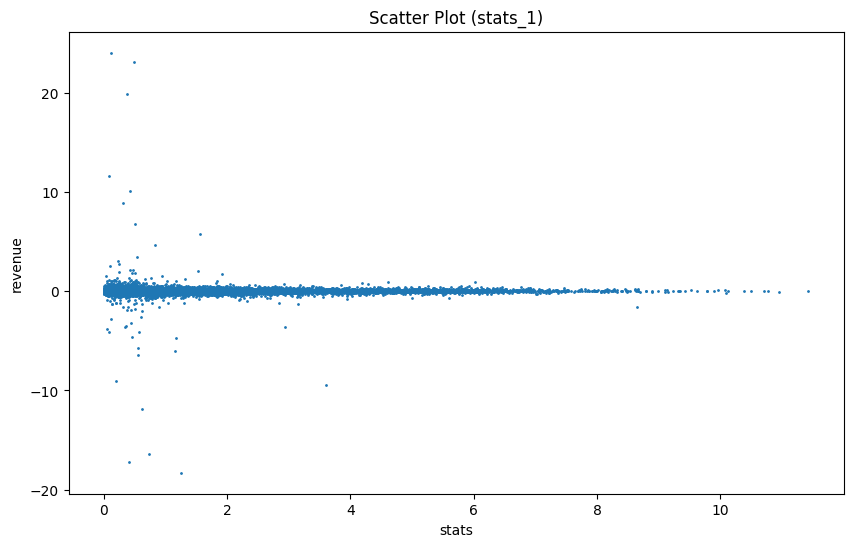

<Figure size 1200x600 with 0 Axes>

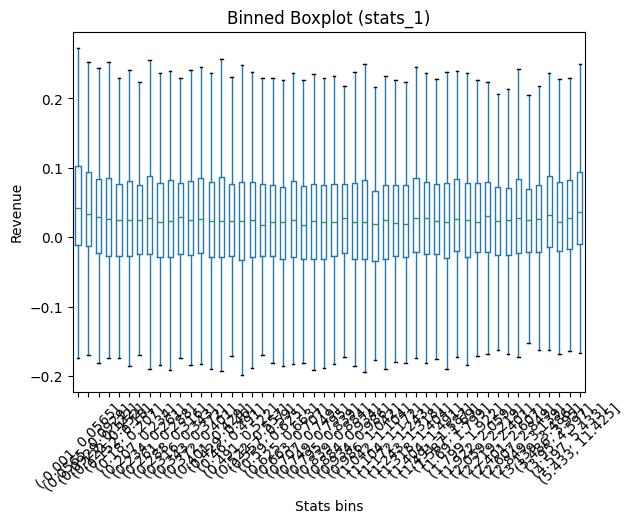

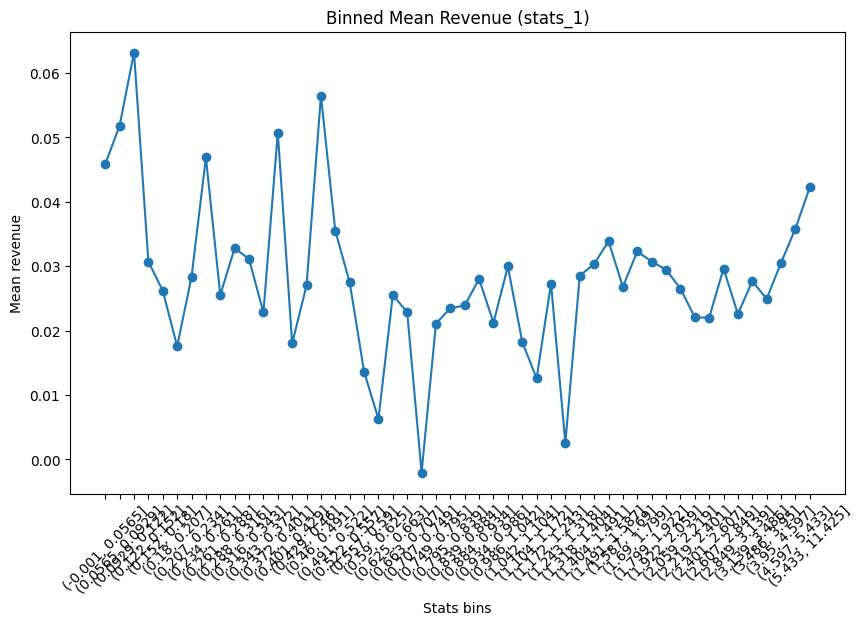


Summary statistics for stats_1:
                  count      mean    median       std
bin                                                  
(-0.001, 0.0565]    863  0.045817  0.041648  0.180036
(0.0565, 0.0929]    863  0.051827  0.033343  0.438391
(0.0929, 0.122]     863  0.063154  0.028631  0.836976
(0.122, 0.152]      863  0.030693  0.025686  0.137494
(0.152, 0.18]       863  0.026198  0.024359  0.134790
(0.18, 0.207]       862  0.017555  0.024355  0.339050
(0.207, 0.234]      863  0.028327  0.024440  0.124882
(0.234, 0.261]      863  0.046868  0.028185  0.210686
(0.261, 0.288]      863  0.025531  0.021971  0.117676
(0.288, 0.316]      863  0.032819  0.023642  0.328421
(0.316, 0.343]      862  0.031093  0.029537  0.115073
(0.343, 0.372]      863  0.022819  0.024713  0.212042
(0.372, 0.401]      863  0.050739  0.026288  0.692061
(0.401, 0.429]      863  0.018019  0.023490  0.693677
(0.429, 0.46]       863  0.027019  0.022837  0.257035
(0.46, 0.491]       862  0.056437  0.023415  0.80

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_11720/145681270.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("bin")["revenue"].agg(


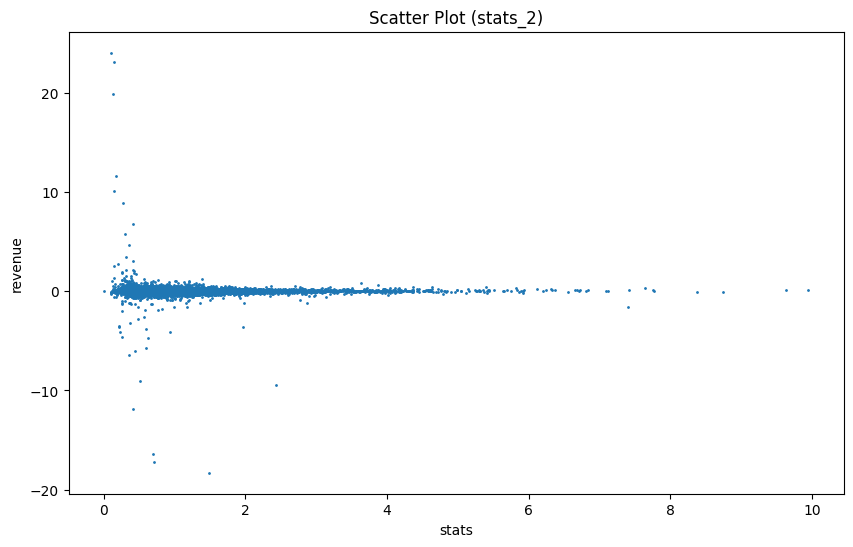

<Figure size 1200x600 with 0 Axes>

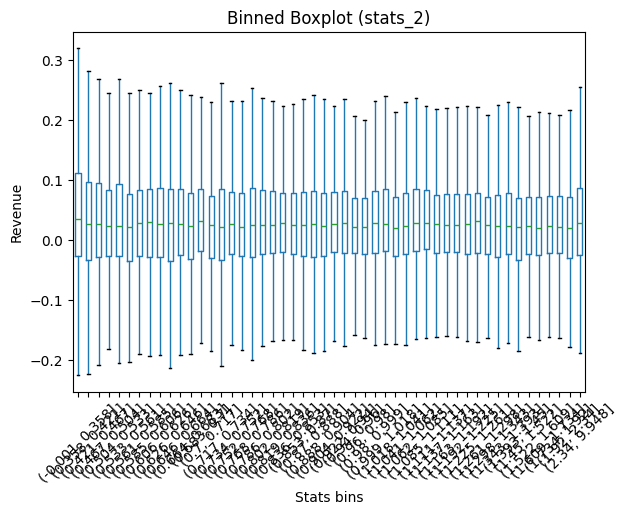

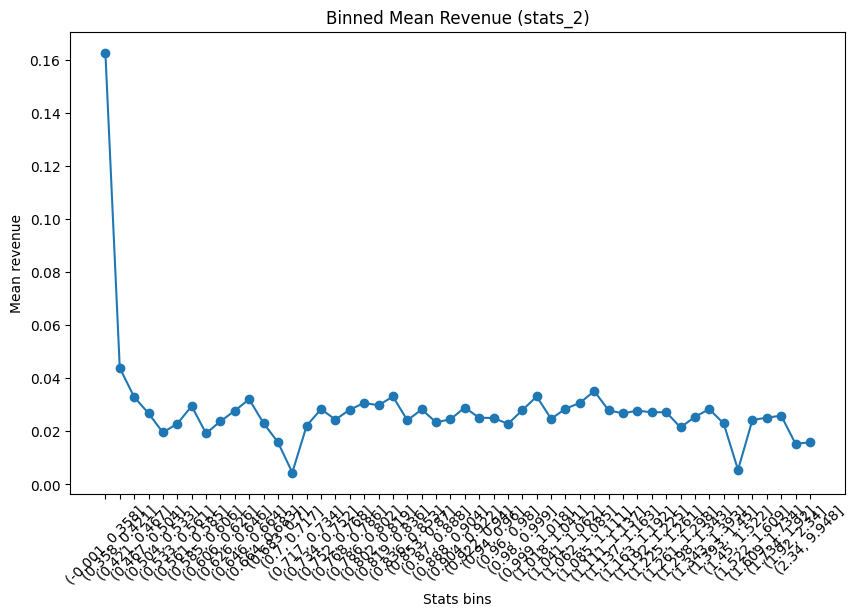


Summary statistics for stats_2:
                 count      mean    median       std
bin                                                 
(-0.001, 0.358]    863  0.162750  0.034711  1.533725
(0.358, 0.421]     863  0.043846  0.025645  0.556377
(0.421, 0.467]     863  0.032911  0.025690  0.277863
(0.467, 0.504]     863  0.026736  0.023642  0.165835
(0.504, 0.533]     863  0.019516  0.023306  0.334618
(0.533, 0.561]     862  0.022810  0.021762  0.122915
(0.561, 0.585]     863  0.029462  0.027305  0.156527
(0.585, 0.606]     863  0.019180  0.030454  0.274350
(0.606, 0.626]     863  0.023713  0.025885  0.199114
(0.626, 0.646]     863  0.027724  0.027546  0.120972
(0.646, 0.664]     862  0.032031  0.025709  0.120551
(0.664, 0.683]     863  0.023012  0.022277  0.130519
(0.683, 0.7]       863  0.015837  0.031050  0.569352
(0.7, 0.717]       863  0.004410  0.025387  0.598838
(0.717, 0.734]     863  0.022075  0.021979  0.121016
(0.734, 0.752]     862  0.028316  0.026656  0.108161
(0.752, 0.768

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_11720/145681270.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df.groupby("bin")["revenue"].agg(


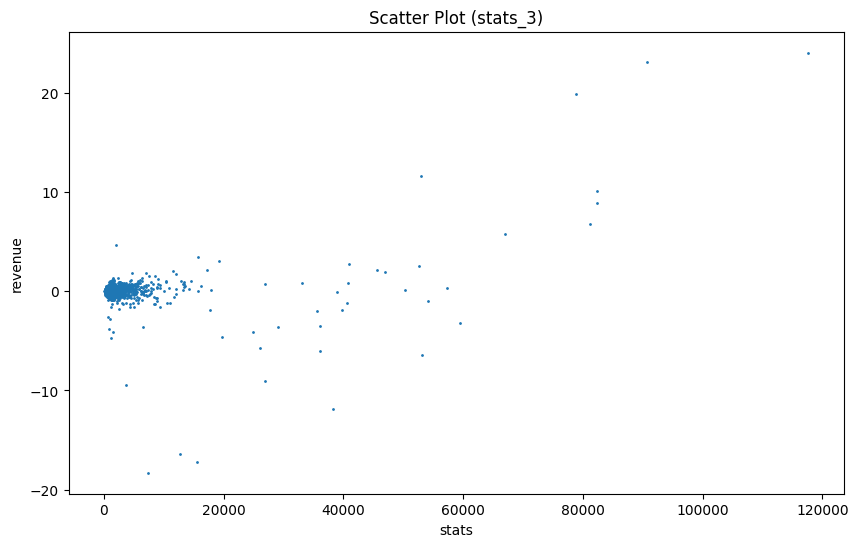

<Figure size 1200x600 with 0 Axes>

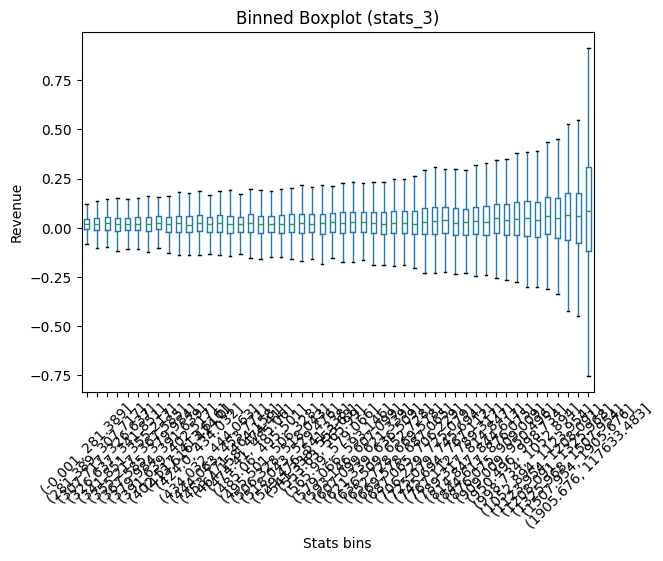

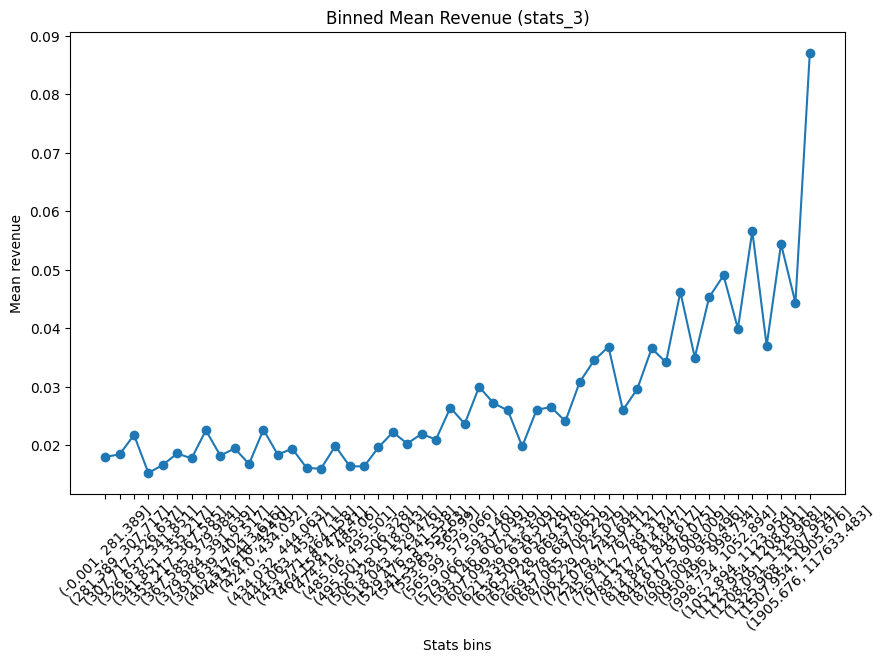


Summary statistics for stats_3:
                        count      mean    median       std
bin                                                        
(-0.001, 281.389]         863  0.018037  0.018725  0.046379
(281.389, 307.717]        863  0.018467  0.018952  0.048163
(307.717, 326.637]        863  0.021787  0.022053  0.052359
(326.637, 341.851]        863  0.015290  0.016927  0.057035
(341.851, 355.217]        863  0.016663  0.017392  0.062363
(355.217, 367.585]        862  0.018626  0.018409  0.057080
(367.585, 379.984]        863  0.017785  0.017735  0.063600
(379.984, 391.639]        863  0.022578  0.021583  0.058579
(391.639, 402.517]        863  0.018261  0.018899  0.065193
(402.517, 413.616]        863  0.019484  0.022372  0.070611
(413.616, 424.0]          862  0.016836  0.015989  0.070932
(424.0, 434.032]          863  0.022702  0.022562  0.071510
(434.032, 444.063]        863  0.018409  0.019333  0.071458
(444.063, 453.771]        863  0.019465  0.021698  0.074167
(453.77

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n_bins = 50  # 分箱数量，可调整

for i, stats in enumerate([stats_1_series, stats_2_series, stats_3_series], start=1):

    df = pd.DataFrame({
        "stats": stats,
        "revenue": revenue_series
    }).dropna()

    # 等频分箱（推荐用于分布不均）
    df["bin"] = pd.qcut(df["stats"], q=n_bins, duplicates="drop")

    # 分箱统计
    bin_stats = df.groupby("bin")["revenue"].agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )

    # ===== 1. 原始散点图 =====
    plt.figure(figsize=(10, 6))
    plt.scatter(df["stats"], df["revenue"], s=1)
    plt.xlabel("stats")
    plt.ylabel("revenue")
    plt.title(f"Scatter Plot (stats_{i})")
    plt.show()
    plt.close()

    # ===== 2. 分箱箱线图 =====
    plt.figure(figsize=(12, 6))
    df.boxplot(
        column="revenue",
        by="bin",
        showfliers=False,
        grid=False
    )
    plt.xticks(rotation=45)
    plt.xlabel("Stats bins")
    plt.ylabel("Revenue")
    plt.title(f"Binned Boxplot (stats_{i})")
    plt.suptitle("")
    plt.show()
    plt.close()

    # ===== 3. 分箱均值曲线 =====
    plt.figure(figsize=(10, 6))
    plt.plot(
        range(len(bin_stats)),
        bin_stats["mean"].values,
        marker="o"
    )
    plt.xticks(range(len(bin_stats)), bin_stats.index.astype(str), rotation=45)
    plt.xlabel("Stats bins")
    plt.ylabel("Mean revenue")
    plt.title(f"Binned Mean Revenue (stats_{i})")
    plt.show()
    plt.close()

    # ===== 4. 输出统计表 =====
    print(f"\nSummary statistics for stats_{i}:")
    print(bin_stats)


In [ ]:
all_trades = pd.DataFrame({
    "revenue": stat_3,
    "stats_1": stats_1_series,
    "stats_2": stats_2_series,
    "stats_3": stats_3_series
})